In [158]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

In [159]:
Sentance=["Ali lives in Peshawar",
    "Ahmad lives in Islamabad",
    "Sara works at Google",
    "John works at Microsoft",
    "Bilal studies in Pehsware pakistan",
    "Mary works at Amazon",
    "Usman lives in Lahore",
    "Ayesha works at OpenAI"]


In [160]:
labels = [
    ["PER", "O", "O", "LOC"],
    ["PER", "O", "O", "LOC"],
    ["PER", "O", "O", "ORG"],
    ["PER", "O", "O", "ORG"],
    ["PER", "O", "O", "LOC","LOC"],
    ["PER", "O", "O", "ORG"],
    ["PER", "O", "O", "LOC"],
    ["PER", "O", "O", "ORG"]
]



In [161]:
# for line in Sentance:
#     line=line.strip().lower()
#     print(line)

In [162]:
### covert the word into the tokenizer means that split it into word by word
tok=Tokenizer()

In [163]:
tok.fit_on_texts(Sentance)

In [164]:
tok.word_index

{'in': 1,
 'works': 2,
 'at': 3,
 'lives': 4,
 'ali': 5,
 'peshawar': 6,
 'ahmad': 7,
 'islamabad': 8,
 'sara': 9,
 'google': 10,
 'john': 11,
 'microsoft': 12,
 'bilal': 13,
 'studies': 14,
 'pehsware': 15,
 'pakistan': 16,
 'mary': 17,
 'amazon': 18,
 'usman': 19,
 'lahore': 20,
 'ayesha': 21,
 'openai': 22}

In [165]:
### make the sequences
seq=tok.texts_to_sequences(Sentance)
seq

[[5, 4, 1, 6],
 [7, 4, 1, 8],
 [9, 2, 3, 10],
 [11, 2, 3, 12],
 [13, 14, 1, 15, 16],
 [17, 2, 3, 18],
 [19, 4, 1, 20],
 [21, 2, 3, 22]]

In [166]:
### now we well make the padding becz the input size is varying 
max_len=(max(len(s) for s in seq))
max_len


5

In [167]:
pad_seq=pad_sequences(seq,maxlen=max_len,padding='post')
pad_seq

array([[ 5,  4,  1,  6,  0],
       [ 7,  4,  1,  8,  0],
       [ 9,  2,  3, 10,  0],
       [11,  2,  3, 12,  0],
       [13, 14,  1, 15, 16],
       [17,  2,  3, 18,  0],
       [19,  4,  1, 20,  0],
       [21,  2,  3, 22,  0]], dtype=int32)

In [168]:
#### label encoding means that we assign the number to every label 
label_id={
    "O":0,
    "PER":1,
    "ORG":2,
    "LOC":3
}

In [169]:
label_id

{'O': 0, 'PER': 1, 'ORG': 2, 'LOC': 3}

In [170]:
### now we will prepare the target column 
y = []

for label_sentence in labels:
    sentence_labels = []

    for label in label_sentence:
        sentence_labels.append(label_id[label])

    y.append(sentence_labels)
y


[[1, 0, 0, 3],
 [1, 0, 0, 3],
 [1, 0, 0, 2],
 [1, 0, 0, 2],
 [1, 0, 0, 3, 3],
 [1, 0, 0, 2],
 [1, 0, 0, 3],
 [1, 0, 0, 2]]

In [171]:
y_pad=pad_sequences(y,maxlen=max_len,padding="post")
y_pad

array([[1, 0, 0, 3, 0],
       [1, 0, 0, 3, 0],
       [1, 0, 0, 2, 0],
       [1, 0, 0, 2, 0],
       [1, 0, 0, 3, 3],
       [1, 0, 0, 2, 0],
       [1, 0, 0, 3, 0],
       [1, 0, 0, 2, 0]], dtype=int32)

In [172]:
voab=len(tok.word_index)+1

In [173]:
voab

23

In [174]:
### make the GRU model
model=Sequential([
     Embedding(
        input_dim=voab,
        output_dim=32
    ),

    GRU(
        64,
        return_sequences=True
    ),

    Dense(
        4,
        activation="softmax"
    )
])


In [175]:
model.compile( optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

In [178]:
seq = np.array(pad_seq)
y = np.array(y_pad)

In [182]:
history=model.fit(
    seq,
    y,
    epochs=10
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 1.0000 - loss: 0.0038
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.0038
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 1.0000 - loss: 0.0036
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.0036
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0035
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.0034
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 0.0034


In [183]:
history.history

{'accuracy': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'loss': [0.0038141540717333555,
  0.0037644878029823303,
  0.003715908620506525,
  0.0036683983635157347,
  0.0036219111643731594,
  0.0035763971973210573,
  0.003531867638230324,
  0.0034882717300206423,
  0.0034455549903213978,
  0.0034037181176245213]}

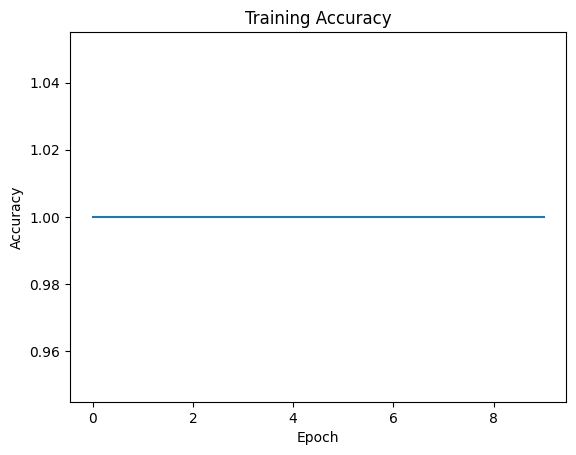

In [185]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

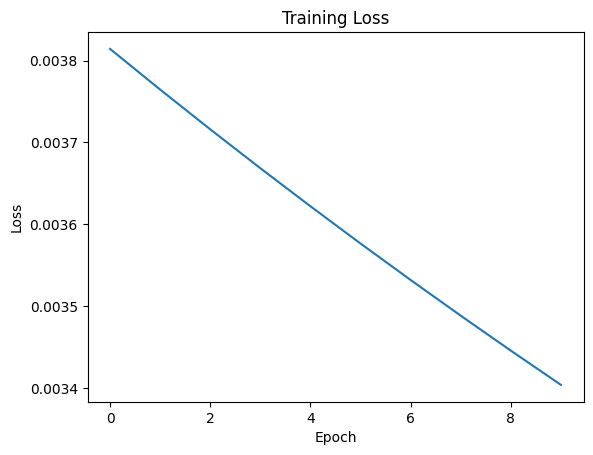

In [186]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()